# DATATHON 2026 — THE GRIDBREAKER
**Hosted by:** VinTelligence - VinUniversity Data Science & AI Club

---

## THÔNG TIN NHÓM
- **Tên đội thi**: Last Dance
- **Mã đội thi**: kVmzJpHWUFT6mv82wG4U
- **Thành viên**: 

| STT | Họ và tên        |  Vai trò   | Email |
| --- | ---------------- | ---------- | ----- |
| 1   | Bùi Lê Khôi      | Đội trưởng |       |
| 2   | Nguyễn Hà Anh    | Thành viên |       |
| 3   | Bùi Công Mậu     | Thành viên |       |
| 4   | Thái Hữu Thọ     | Thành viên |       |

---

## GIỚI THIỆU FILE NOTEBOOK

- **Mục đích**: Thực hiện train mô hình - **Phần 3 — Mô hình Dự báo Doanh thu (Sales Forecasting)**

- **Nội dung trong file**:

    - 

- **Dữ liệu sử dụng**:
    - Dữ liệu đầu vào là file dữ liệu đã đc xử lí sau khi chạy file LD_03_Model_01_Preprocessing.
    
---

Bài làm được trình bày từ sau dòng này.

---
---

### Import các libs và dependencies

In [11]:
import re
import os
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl as pxl
import seaborn as sns
import statsmodels.api as sm
import datetime as dt

from datetime import timedelta
from scipy import stats
from math import sqrt

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, pairwise_distances, silhouette_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

import warnings
warnings.filterwarnings("ignore")

# Ensure plots appear in the notebook
%matplotlib inline

# Print last updated timestamp
import time
print(f"Cập nhật lần cuối vào thời điểm {time.asctime()}")


Cập nhật lần cuối vào thời điểm Thu Apr 30 11:39:30 2026


In [12]:
# --- MASTER JOIN & DATA PREPARATION ---

training_dir = '../data/training'
sales = pd.read_csv(f"{training_dir}/sales.csv")
products = pd.read_csv(f"{training_dir}/products.csv")

# Chuẩn hóa tên cột
sales.columns = [col.lower() for col in sales.columns]
products.columns = [col.lower() for col in products.columns]

# KIỂM TRA: Nếu bảng sales thiếu product_id, ta không thể merge theo cách thông thường.
# Ở đây ta sẽ tập trung train trên các đặc trưng thời gian đã có trong bảng sales.

if 'product_id' in sales.columns:
    df_master = sales.merge(products, on='product_id', how='left')
    print("Merge thành công bảng Sales và Products.")
else:
    print("Cảnh báo: Không tìm thấy 'product_id' trong bảng sales. Huấn luyện dựa trên features thời gian.")
    df_master = sales

# Xác định Target là Revenue (Dựa trên danh sách cột bạn cung cấp)
target_col = 'revenue'

# Lấy các cột số làm Features (month, day, day_of_week, v.v.)
# Loại bỏ target và các cột không phải số
features = df_master.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')
target = df_master[target_col]

# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print(f"Target: {target_col}")
print(f"Features: {features.columns.tolist()}")

Cảnh báo: Không tìm thấy 'product_id' trong bảng sales. Huấn luyện dựa trên features thời gian.
Target: revenue
Features: ['cogs', 'month', 'day_of_week', 'is_weekend', 'day']


---

--- Đang bắt đầu quá trình huấn luyện đa mô hình ---
Hoàn thành: Linear Regression    | R2: 0.9579
Hoàn thành: Ridge Regression     | R2: 0.9579
Hoàn thành: Lasso Regression     | R2: 0.9579
Hoàn thành: KNN Regressor        | R2: 0.9465
Hoàn thành: Random Forest        | R2: 0.9609
Hoàn thành: Gradient Boosting    | R2: 0.9655
Hoàn thành: XGBoost              | R2: 0.9635

BẢNG XẾP HẠNG CÁC MÔ HÌNH (Sắp xếp theo R2 Score):
               Model            MAE           RMSE  R2 Score
5  Gradient Boosting  294156.050339  486927.095592  0.965495
6            XGBoost  259849.487487  500499.376006  0.963545
4      Random Forest  294612.863110  518247.042283  0.960913
1   Ridge Regression  367523.097517  538079.239107  0.957865
0  Linear Regression  367523.373377  538079.353556  0.957865
2   Lasso Regression  367523.383878  538079.353781  0.957865
3      KNN Regressor  406491.712657  606536.173721  0.946461


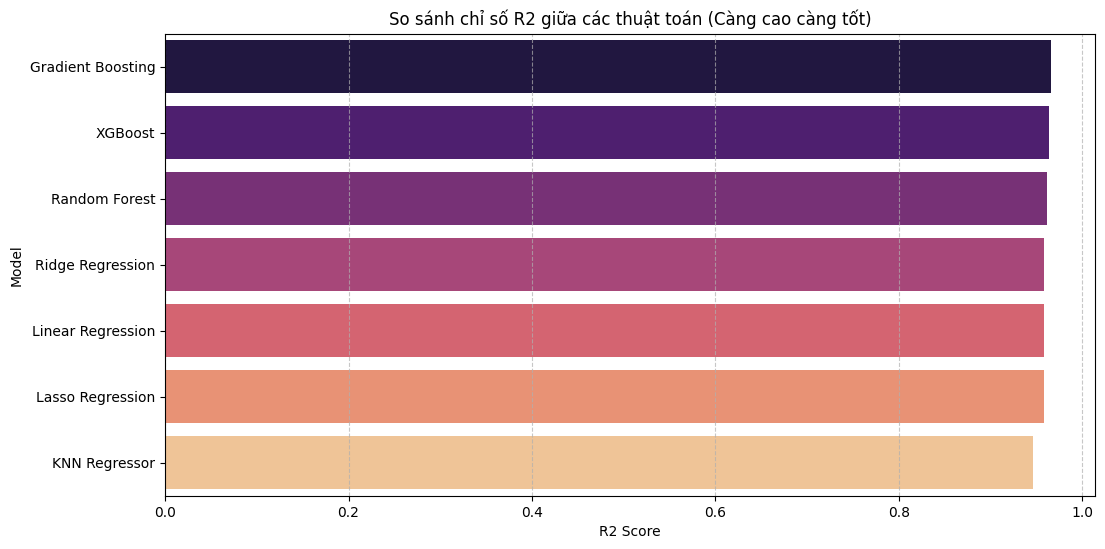


=> Mô hình tốt nhất dựa trên R2 Score là: Gradient Boosting


In [13]:
# --- BƯỚC 2: MULTI-MODEL TRAINING & EVALUATION ---

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

# 1. Khởi tạo danh sách các mô hình
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Thêm XGBoost nếu có thư viện
if XGBRegressor:
    models["XGBoost"] = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# 2. Vòng lặp huấn luyện và đánh giá
model_results = []

print("--- Đang bắt đầu quá trình huấn luyện đa mô hình ---")

for name, model in models.items():
    # Huấn luyện mô hình
    model.fit(X_train, y_train)
    
    # Dự báo trên tập test
    y_pred = model.predict(X_test)
    
    # Tính toán các chỉ số đo lường
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    model_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })
    print(f"Hoàn thành: {name:20} | R2: {r2:.4f}")

# --- BƯỚC 3: SO SÁNH VÀ TRỰC QUAN HÓA ---

# Chuyển kết quả thành DataFrame để dễ so sánh
df_comparison = pd.DataFrame(model_results).sort_values(by="R2 Score", ascending=False)

print("\nBẢNG XẾP HẠNG CÁC MÔ HÌNH (Sắp xếp theo R2 Score):")
print(df_comparison)

# Trực quan hóa kết quả bằng biểu đồ cột
plt.figure(figsize=(12, 6))
sns.barplot(x='R2 Score', y='Model', data=df_comparison, palette='magma')
plt.title('So sánh chỉ số R2 giữa các thuật toán (Càng cao càng tốt)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- BƯỚC 4: LỰA CHỌN VÀ LƯU MÔ HÌNH TỐT NHẤT ---

best_model_name = df_comparison.iloc[0]['Model']
print(f"\n=> Mô hình tốt nhất dựa trên R2 Score là: {best_model_name}")

# Lưu mô hình tốt nhất để sử dụng sau này
best_model_obj = models[best_model_name]
# joblib.dump(best_model_obj, 'best_sales_forecasting_model.pkl')

In [14]:
# --- BƯỚC 5: TINH CHỈNH GRADIENT BOOSTING ---

# Định nghĩa các không gian tham số cần tối ưu
param_grid = {
    'n_estimators': [100, 200, 300], # Số lượng cây
    'learning_rate': [0.01, 0.05, 0.1], # Tốc độ học
    'max_depth': [3, 4, 5], # Độ sâu tối đa của cây
    'subsample': [0.8, 0.9, 1.0], # Tỷ lệ dữ liệu dùng để huấn luyện mỗi cây
    'min_samples_split': [2, 5]
}

# Khởi tạo mô hình Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)

# Thiết lập GridSearch với Cross-validation
grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=3, # Chia 3 tập để kiểm tra chéo
    scoring='r2',
    n_jobs=-1, # Sử dụng tất cả các nhân CPU để chạy nhanh hơn
    verbose=1
)

print("Đang bắt đầu tinh chỉnh tham số cho Gradient Boosting...")
grid_search_gb.fit(X_train, y_train)

# Lưu lại model tốt nhất sau khi tinh chỉnh
final_model_gb = grid_search_gb.best_estimator_

print(f"\nTham số tốt nhất tìm được: {grid_search_gb.best_params_}")
print(f"R2 Score tốt nhất trên tập Validation: {grid_search_gb.best_score_:.4f}")

Đang bắt đầu tinh chỉnh tham số cho Gradient Boosting...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Tham số tốt nhất tìm được: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 0.9}
R2 Score tốt nhất trên tập Validation: 0.9619


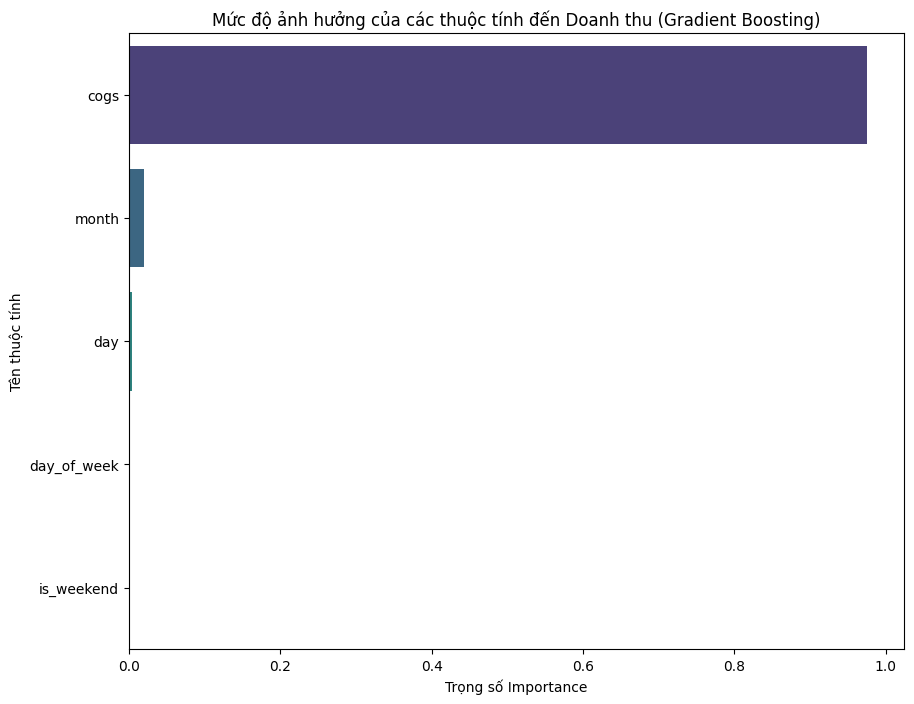

Top 3 thuộc tính quan trọng nhất:
  Feature  Importance
0    cogs    0.975334
1   month    0.020113
4     day    0.003512


In [15]:
# --- BƯỚC 6: PHÂN TÍCH TÍNH NĂNG QUAN TRỌNG ---

# Lấy giá trị importance từ mô hình cuối cùng
importances = final_model_gb.feature_importances_
feature_names = features.columns

# Tạo DataFrame để trực quan hóa
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Mức độ ảnh hưởng của các thuộc tính đến Doanh thu (Gradient Boosting)')
plt.xlabel('Trọng số Importance')
plt.ylabel('Tên thuộc tính')
plt.show()

print("Top 3 thuộc tính quan trọng nhất:")
print(importance_df.head(3))